<a href="https://colab.research.google.com/github/pazylkhann/d2l.ai-learning-process/blob/main/Preliminaries/Autograd.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Automatic Differentiation

In [34]:
import torch

##A Simple Function

In [35]:
x = torch.arange(4.0)
x

tensor([0., 1., 2., 3.])

In [36]:
# Can also create x = torch.arange(4.0, requires_grad=True)
x.requires_grad_(True)
x.grad

In [37]:
y = 2 * torch.dot(x, x)
y

tensor(28., grad_fn=<MulBackward0>)

In [38]:
y.backward()      # taking gradient of y with respect to x by calling backward
x.grad      # calling gradient itself

tensor([ 0.,  4.,  8., 12.])

In [39]:
x.grad == 4 * x           # We know that grad is equal to 4x, but also we can verify it with this operation

tensor([True, True, True, True])

In [40]:
x.grad.zero_()    # Reset the gradient
y = x.sum()       # Change the function
y.backward()
x.grad

tensor([1., 1., 1., 1.])

## Backward for Non-Scalar Variables

In [41]:
x.grad.zero_()
y = x * x
y.backward(gradient=torch.ones(len(y)))  # Faster: y.sum().backward()
x.grad

tensor([0., 2., 4., 6.])

##Detaching Computation

In [42]:
x.grad.zero_()
y = x * x
u = y.detach()     # By detaching y we want to understand direct influence of x to z as we consider u as static vector with no ancestors
z = u * x

z.sum().backward()
x.grad == u

tensor([True, True, True, True])

In [43]:
x.grad.zero_()
y.sum().backward()     # after detaching y will be disconnected from z, but still connected to x
x.grad == 2*x

tensor([True, True, True, True])

##Gradients and Python Control Flow

In [44]:
def f(a):
  b = a * 2
  while b.norm() < 1000:
    b = b * 2
  if b.sum() > 0:
    c = b
  else:
    c = 100 * b
  return c

In [45]:
a = torch.randn(size=(), requires_grad=True)
d = f(a)
d.backward()

In [46]:
a.grad == d / a

tensor(True)

##Exercises

In [50]:
# Exercise number 3
l = torch.arange(1.0, 6.0, requires_grad=True)
e = f(l)
e.sum().backward()
l.grad == e / l

tensor([True, True, True, True, True])

In [54]:
import matplotlib.pyplot as plt
import math
import numpy as np

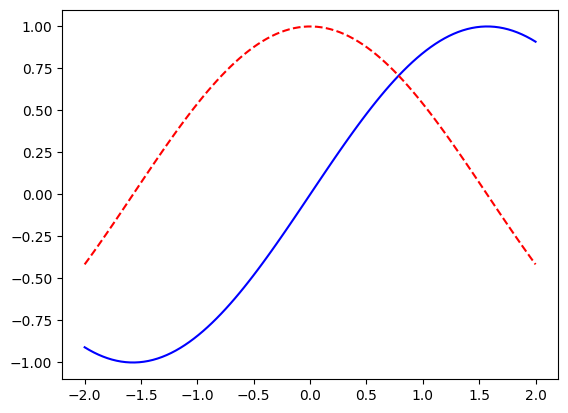

In [66]:
# Exercise 4
def f(x):
  return torch.sin(x)
x = torch.linspace(-2, 2, 100, requires_grad=True)
y = f(x)
y.sum().backward()
plt.plot(x.detach(), y.detach(), label='sin(x)', color='blue')
plt.plot(x.detach(), x.grad, label='derivative of sin(x) by using only basic operations', color='red', linestyle='--')
plt.show()
